## Testing MSS2
This notebook is to import and check the format etc of the different MSS2 maps that will be used for testing the effect of filtering on MEGATOP.

MSS2 useful links: \
https://simonsobs.atlassian.net/wiki/spaces/PRO/pages/147620118/Mission+scale+simulation+2+execution \
https://simonsobs.atlassian.net/wiki/spaces/PRO/pages/11012339/Mission+Scale+Simulation+2+plan \
https://github.com/simonsobs/pwg-scripts/tree/master/pwg-tds/mss-0002/sat \
https://github.com/simonsobs/pwg-scripts/blob/master/pwg-tds/mss-0002/sat/test_obsmat.py \
https://github.com/simonsobs/pwg-scripts/blob/master/pwg-tds/mss-0002/sat/plot_coadds.py

### Sky model and instrument model used:
https://github.com/simonsobs/map_based_simulations/blob/master/mbs-s0012-20230321/README.md

MSS2 simulations are run using bandpasses, the above readme links to this [notebook](https://github.com/simonsobs/map_based_simulations/blob/master/mbs-s0012-20230321/simonsobs_instrument_parameters_2023.03/extract_so_instrument_parameters.ipynb) to get more info, as well as this [repo](https://github.com/simonsobs/instrument_model/tree/master/instrument_hardware/modeled_bandpasses) used to compute the bandpasses (not entirely sure to be checked)

The foreground model used is the "Medium Complexity" as defined by the [Panexperiment Galactic Science Group](https://galsci.github.io/blog/2022/common-fiducial-sky/)  `d10,s5,f1,a1,co3`



In [2]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
from megatop import BBmeta


In [3]:
freq = 150
tele = 'SAT1'
band = f"f{freq:03}"
split = 0

print(tele)
print(band)

use_split_coadd = False # if True, use the maps coadding the 4 splits, else use the split maps

if use_split_coadd:
    coad_output = f"/global/cfs/cdirs/sobs/sims/mss-0002/RC1.r01/sobs_RC1.r01_{tele}_mission_{band}_4way_coadd_sky_map_healpix.fits"
    cmb_output = f"/global/cfs/cdirs/sobs/sims/mss-0002/RC1.r01/sobs_RC1.r01_{tele}_mission_{band}_4way_coadd_cmb_map_healpix.fits"
    fg_output = f"/global/cfs/cdirs/sobs/sims/mss-0002/RC1.r01/sobs_RC1.r01_{tele}_mission_{band}_4way_coadd_foreground_map_healpix.fits"
    nhits_path = f"/global/cfs/cdirs/sobs/sims/mss-0002/RC1.r01/sobs_RC1.r01_{tele}_mission_{band}_4way_coadd_sky_ivar_healpix.fits"

else:
    coad_output = f"/global/cfs/cdirs/sobs/sims/mss-0002/RC1.r01/sobs_RC1.r01_{tele}_mission_{band}_4way_split{split}_sky_map_healpix.fits"
    cmb_output = f"/global/cfs/cdirs/sobs/sims/mss-0002/RC1.r01/sobs_RC1.r01_{tele}_mission_{band}_4way_split{split}_cmb_map_healpix.fits"
    fg_output = f"/global/cfs/cdirs/sobs/sims/mss-0002/RC1.r01/sobs_RC1.r01_{tele}_mission_{band}_4way_split{split}_foreground_map_healpix.fits"
    nhits_path = f"/global/cfs/cdirs/sobs/sims/mss-0002/RC1.r01/sobs_RC1.r01_{tele}_mission_{band}_4way_split{split}_sky_ivar_healpix.fits"

path_flavors = {
    'coadded': coad_output,
    'CMB': cmb_output,
    'foreground': fg_output,
    'nhits': nhits_path,
}

SAT1
f150


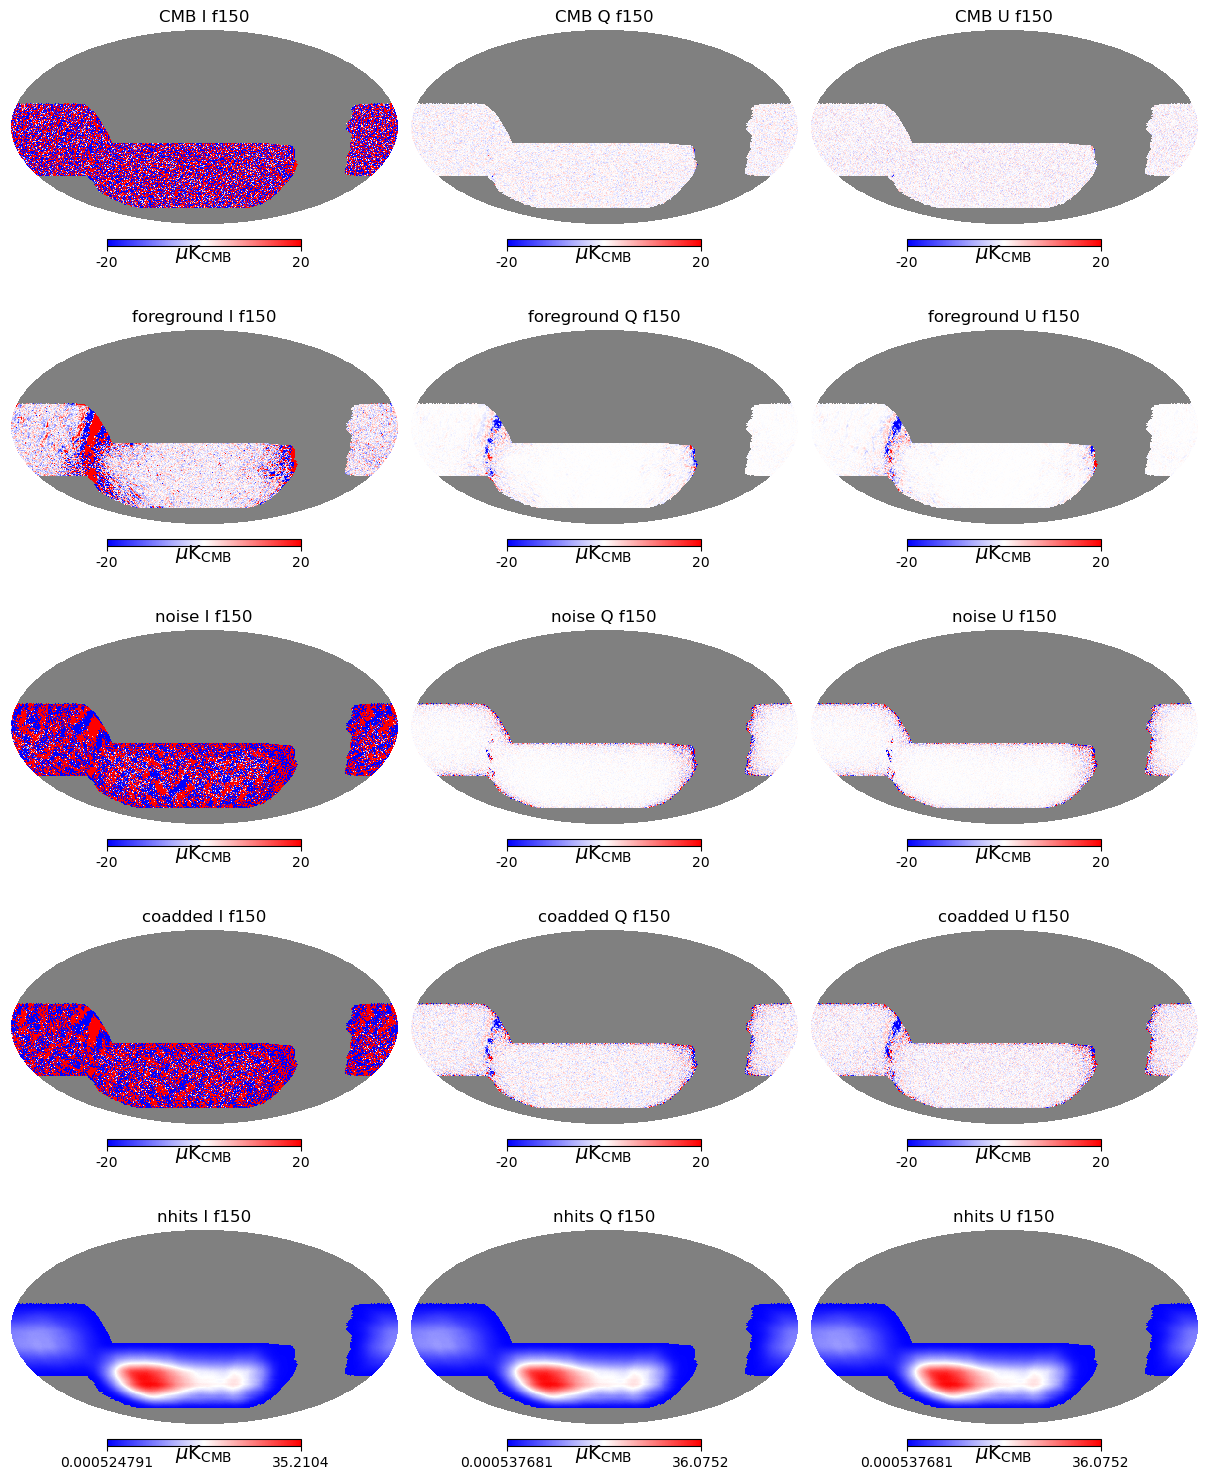

In [43]:

plt.close()
flavors = ['CMB', 'foreground', 'noise', 'coadded', 'nhits']
nrow = len(flavors)
ncol = 3
stokes_name = ['I', 'Q', 'U']
# fig, axes = plt.subplots(nrow, ncol, figsize=(16, 4))
fig = plt.figure(figsize=[4 * ncol, 3 * nrow])

iplot = 0
for flavor in flavors:
    # print(flavor)
    for stoke in range(3):
        iplot += 1
        # print('stoke =', stokes_name[stoke])
        if flavor != 'noise':
            map_flav_s = hp.read_map(path_flavors[flavor], field=stoke)
        else:
            coadd = hp.read_map(path_flavors['coadded'], field=stoke)
            fg = hp.read_map(path_flavors['foreground'], field=stoke)
            cmb = hp.read_map(path_flavors['CMB'], field=stoke)
            map_flav_s = coadd - fg - cmb
        observed = map_flav_s != 0

        unit="$\mu$K$_\mathrm{CMB}$"
        map_flav_s[map_flav_s == 0] = hp.UNSEEN
        offset = np.median(map_flav_s[observed])
        # print('offset= ',offset)
        rms = np.std(map_flav_s[observed])
        amp = 2 * rms
        # print('amp =', amp)

        if flavor == 'nhits':
            min, max = None, None
        else:
            min, max = -20, 20
            # min, max = offset - amp, offset + amp
        hp.mollview(map_flav_s,cmap="bwr",
                    min=min,max=max,
                    sub=[nrow, ncol, iplot],
                    title=f"{flavor} {stokes_name[stoke]} {band}",
            unit=unit)
        
        # hp.mollview(
        #     map_flav_s,
        #     min=offset - amp,
        #     max=offset + amp, 
        #     sub=[nrow, ncol, iplot],
        #     cmap="bwr",
        #     title=f"{flavor} {stokes_name[stoke]} {band}",
        #     unit=unit,
        # )


plt.show()
plt.close()



### Comparing the hit maps in the same instrument and frequency band but for 2 different splits and coadded map

In [7]:
nhits_path_coadd = f"/global/cfs/cdirs/sobs/sims/mss-0002/RC1.r01/sobs_RC1.r01_{tele}_mission_{band}_4way_coadd_sky_ivar_healpix.fits"
nhits_path_split0 = f"/global/cfs/cdirs/sobs/sims/mss-0002/RC1.r01/sobs_RC1.r01_{tele}_mission_{band}_4way_split{split}_sky_ivar_healpix.fits"
nhits_path_split2 = f"/global/cfs/cdirs/sobs/sims/mss-0002/RC1.r01/sobs_RC1.r01_{tele}_mission_{band}_4way_split{2}_sky_ivar_healpix.fits"


In [72]:
normalize_nhits = False

nhits_split0 = hp.read_map(nhits_path_split0, field=None)
if normalize_nhits: nhits_split0 = nhits_split0 /  np.max(nhits_split0, axis=1)[:, np.newaxis]
nhits_split0[ nhits_split0 == 0 ] = hp.UNSEEN   

nhits_split2 = hp.read_map(nhits_path_split2, field=None)
if normalize_nhits: nhits_split2 = nhits_split2 /  np.max(nhits_split2, axis=1)[:, np.newaxis]
nhits_split2[ nhits_split2 == 0 ] = hp.UNSEEN


nhits_coadd = hp.read_map(nhits_path_coadd, field=None)
if normalize_nhits: nhits_coadd = nhits_coadd /  np.max(nhits_coadd, axis=1)[:, np.newaxis]
nhits_coadd[ nhits_coadd == 0 ] = hp.UNSEEN

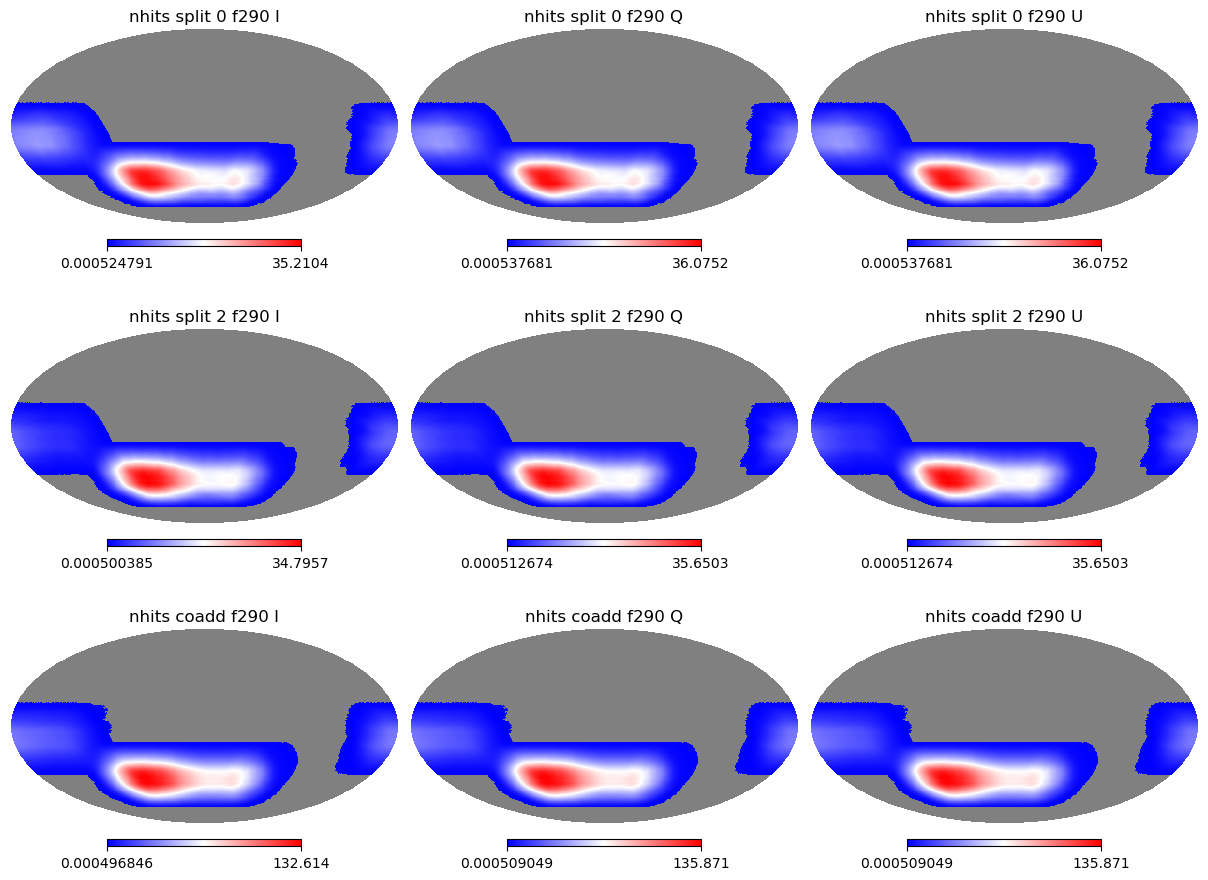

In [73]:
#  plotting the nhits maps
plt.close()
ncol = 3
nrow = 3
fig = plt.figure(figsize=[4 * nrow, 3 * ncol])
for i in range(3):
    hp.mollview(nhits_split0[i], sub=(nrow, ncol, i+1), title=f"nhits split 0 {band} {stokes_name[i]}",cmap="bwr")
    hp.mollview(nhits_split2[i], sub=(nrow, ncol, i+4), title=f"nhits split 2 {band} {stokes_name[i]}",cmap="bwr")
    hp.mollview(nhits_coadd[i], sub=(nrow, ncol, i+7), title=f"nhits coadd {band} {stokes_name[i]}",cmap="bwr")
plt.show()
plt.close()

So nhits between splits are different and it seems that nhits of a given split and frequency are different between intensity and polarization!

### Comparing nhits of different frequency bands (using only the coadded split map version)

/global/cfs/cdirs/sobs/sims/mss-0002/RC1.r01/sobs_RC1.r01_SAT4_mission_f030_4way_coadd_sky_ivar_healpix.fits
/global/cfs/cdirs/sobs/sims/mss-0002/RC1.r01/sobs_RC1.r01_SAT4_mission_f040_4way_coadd_sky_ivar_healpix.fits
/global/cfs/cdirs/sobs/sims/mss-0002/RC1.r01/sobs_RC1.r01_SAT1_mission_f090_4way_coadd_sky_ivar_healpix.fits
/global/cfs/cdirs/sobs/sims/mss-0002/RC1.r01/sobs_RC1.r01_SAT1_mission_f150_4way_coadd_sky_ivar_healpix.fits
/global/cfs/cdirs/sobs/sims/mss-0002/RC1.r01/sobs_RC1.r01_SAT3_mission_f230_4way_coadd_sky_ivar_healpix.fits
/global/cfs/cdirs/sobs/sims/mss-0002/RC1.r01/sobs_RC1.r01_SAT3_mission_f290_4way_coadd_sky_ivar_healpix.fits


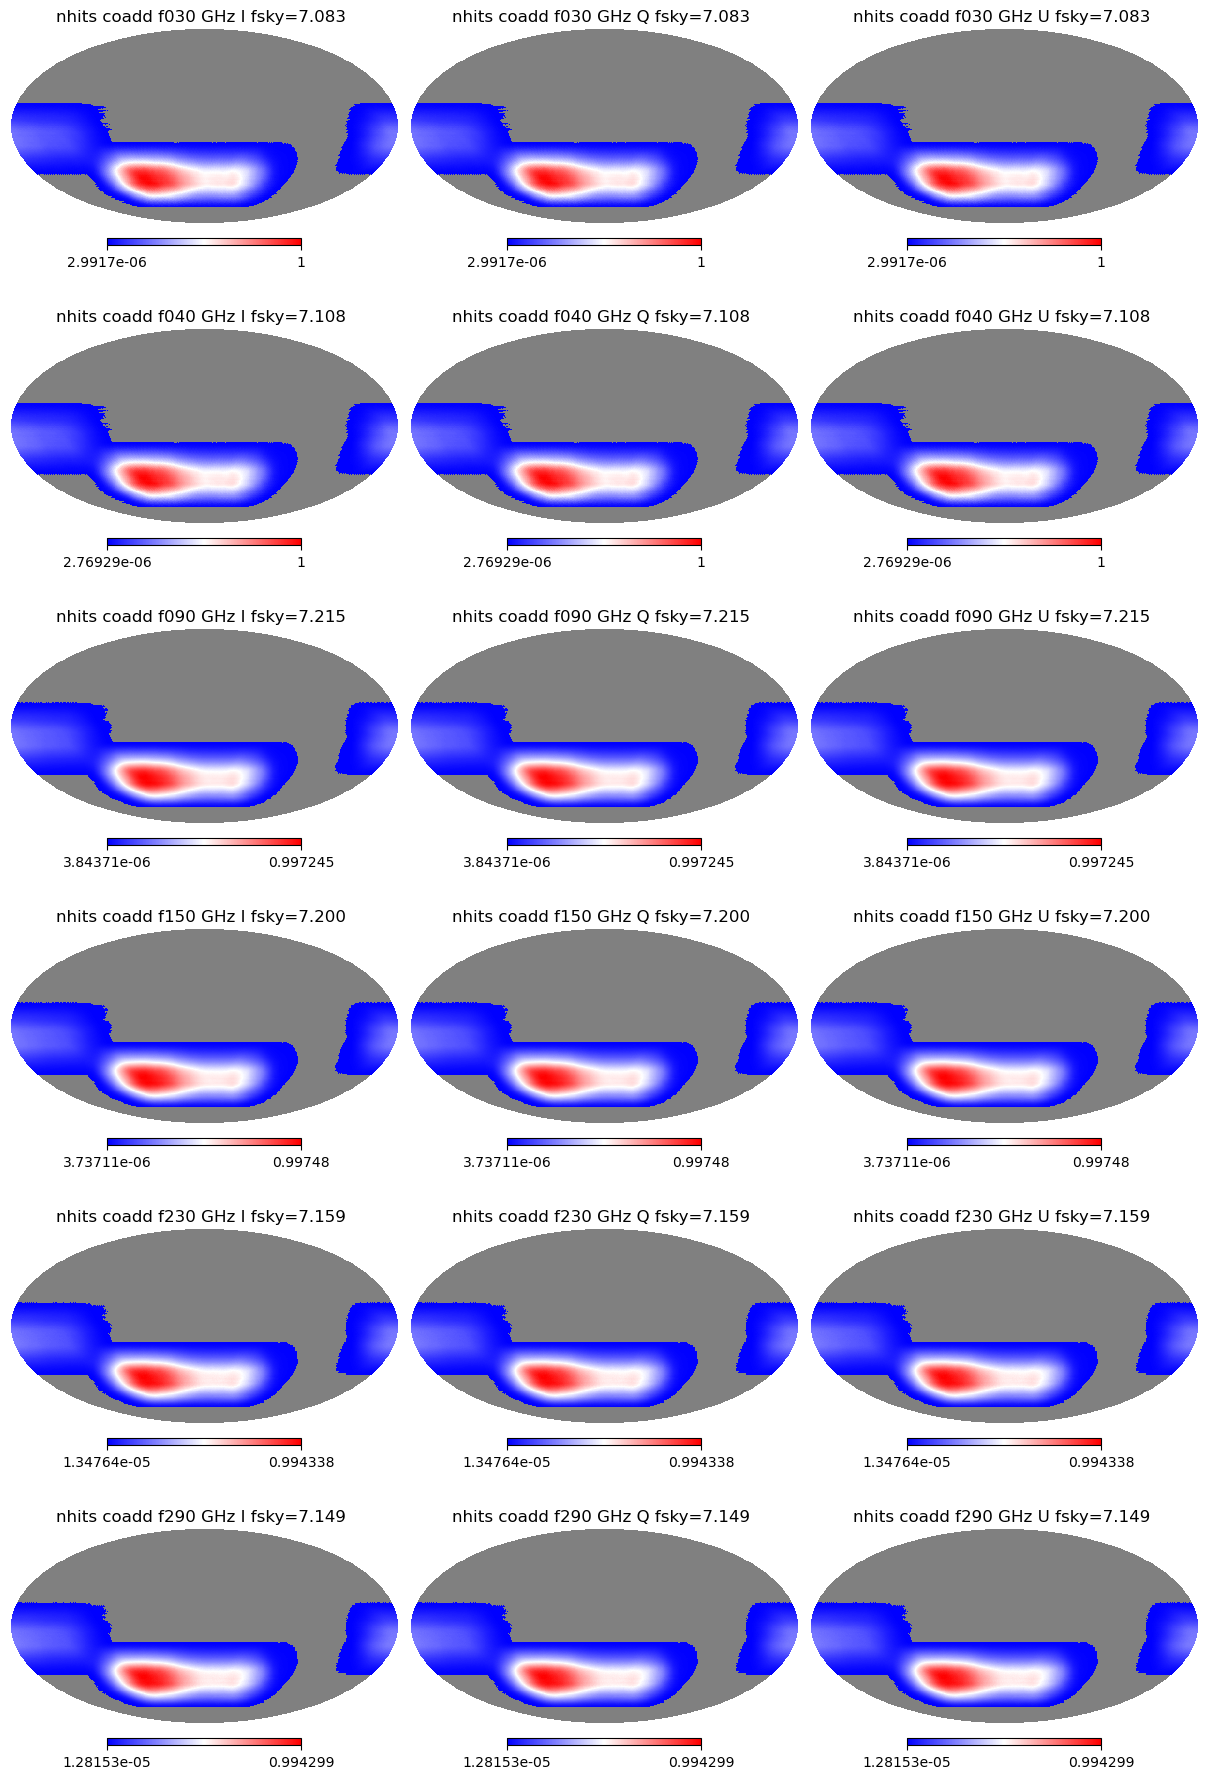

In [76]:
#  plotting the nhits maps
frequencies = [30, 40, 90, 150, 230, 290]
normalize_nhits = True

plt.close()
ncol = 3
nrow = len(frequencies)
fig = plt.figure(figsize=[4 * ncol, 3 * nrow])
i_plot = 0
for freq in frequencies:
    band = f"f{freq:03}"
    if freq < 50:
        tele = "SAT4"
    elif freq > 200:
        tele = "SAT3"
    else:
        tele = "SAT1"
    nhits_path_coadd_freq = f"/global/cfs/cdirs/sobs/sims/mss-0002/RC1.r01/sobs_RC1.r01_{tele}_mission_{band}_4way_coadd_sky_ivar_healpix.fits"
    print(nhits_path_coadd_freq)
    nhits_coadd_freq = hp.read_map(nhits_path_coadd_freq, field=None)
    if normalize_nhits: nhits_coadd_freq = nhits_coadd_freq /  np.max(nhits_coadd_freq, axis=1)[:, np.newaxis]
    fsky = np.mean(nhits_coadd_freq)
    nhits_coadd_freq[ nhits_coadd_freq == 0 ] = hp.UNSEEN   

    for s in range(3):
        i_plot += 1
        hp.mollview(nhits_coadd_freq[s], sub=(nrow, ncol, i_plot), title=f"nhits coadd {band} GHz {stokes_name[s]} fsky={fsky*100:.3f} ",cmap="bwr")

plt.show()
plt.close()

So it seems nhits are different as well between frequency (and associated fsky).
We might need to have a way to build the analysis mask from those and make sure that all pixels inside the mask have been observed at all frequency. Or maybe the component separation can handle pixels that have not necesseraly been observed at all frequencies? 
In any case for the testing of MSS2 I'll just use the coadded maps with a binary mask build from the 30 (26?)GHz nhits maps which has the smallest fsky. 